<a href="https://colab.research.google.com/github/eklavya0948-max/electric-load-forecasting-weather-time/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is LSTM?
Long short term memory or LSTM is a specialised recurrent neural network (RNN) which excels in capturing long term dependencies which make it good choice to predict sequential data with temporal dependencies.

Importing data set

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned data.csv to cleaned data (1).csv


Importing required libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


Loading cleaned data.csv

In [ ]:
df = pd.read_csv("cleaned data.csv")

Defining Features

In [ ]:
data = df[["temperature","humidity","load"]]

Scaling: To normalise values between 0 and 1 to make training process effecient.

In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

Creating Sequence (24 hour)

In [ ]:
X = []
y = []

time_steps = 24

for i in range(time_steps,len(data_scaled)):
    X.append(data_scaled[i-time_steps:i])
    y.append(data_scaled[i,2])

X = np.array(X)
y = np.array(y)


Train Test Split (80% training 20% testing)

In [ ]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


LSTM Model

In [ ]:

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM Model

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.0326 - val_loss: 0.0054
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0122 - val_loss: 0.0047
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0116 - val_loss: 0.0044
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0106 - val_loss: 0.0042
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0092 - val_loss: 0.0046
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0098 - val_loss: 0.0036
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0081 - val_loss: 0.0037
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0075 - val_loss: 0.0038
Epoch 9/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0074 - val_loss: 0.0035
Epoch 10/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.0068 - val_loss: 0.0041
Epoch 11/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0071 - val_loss: 0.0035
Epoch 12/30
219/219 ━━━━━━━━━━━━━━━━━━━

# What are epochs and what 30 epochs and 219 represents?

1. If we take textbook definition of epoch in neural network and machine learning then epoch refers to one complete pass through the entire training data set . In simple words it represents how many time same data is fed to neural network.

For e.g. 1 epoch means model goes through entire training dataset one time.

2 epochs means model goes through entire training data set 2 times.

2. In our case 30 epochs means our model goes through data set 30 times.

3. For each epoch training data is divided into small data chunks called batches. For our data we have batch size= 32 . Since we are using 80% of our total dataset its equal to 8735 *0.8 = 6988 columns . These 6988 columns are divides into batches of 32 columns, the number of batches is calculates ad 6988/32 = 218.375 which is rounded to 219 to ensure all samples are processed. So we have 219 batches with 218 batches of 32 columns and 219th batch with 22 columns.

# What are loss and val_loss?

1. Loss refers to training loss . It measures how well a model's predictions match the actual values for the data it has gone through during training. With each epoch model tries to decrease this value by adjustingits weights on features defined. A decreasing training loss means model is learning pattern. In our case loss at start was 0.0431 which was aleready very small , in the end it was also decreased to $10^{-3}$ .

   i.  It indicates that our model was able to make predictions that were relatively close to the actual values . This suggest that the data is predictable and our features and model framework is suited for thes task .

   ii. The continious decrase in loss value indicates that our model was consistentely learning and improvising to decrease the overall errors.

2. Val_Loss stands for validation loss. It measures how well model's predicition matches actual values which it has not seen during training.

   In our model initial val_loss was 0.0075 which is decreased to 0.0026 by the 30th epoch. This indicates that our model which is quite good from the start to predict unseen data is not only memorising new data but also learning pattern to predict new unseen data.


# What are overall conclusions from loss data and val_loss data ?

 Our loss data is very small and continiously decreasing , same goes with our val_loss data. Combining both results we can conclude that our chosen features and model framework is ideal for our task and since both loss and val_loss values are decreasing our model not only excels in learning training data and patterns but also accurately predict for new unseen data.


Prediction: It is used to store predicitions for evaluation and future forecasting

In [ ]:
pred = model.predict(X_test)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


Inverse Scaling : Converting prediction to original scale for meaningfull inerpretion.

In [ ]:
load_scaler = MinMaxScaler()
load_scaler.fit(df[["load"]])

pred = load_scaler.inverse_transform(pred)
y_test = load_scaler.inverse_transform(y_test.reshape(-1,1))

Evaluation of model using MAE and RMSE

In [ ]:
mae = mean_absolute_error(y_test,pred)
rmse = np.sqrt(mean_squared_error(y_test,pred))

print("MAE:",mae)
print("RMSE:",rmse)

MAE: 180.85436282816266
RMSE: 294.52966239047146


# What are your conclusions on model on the basis of MAE and RMSE values?
Since we lack value of total capacity of substation we will be using maximum observed load to calculate percentage error which is 6306.21 KW.

1. MAE relative to max. observed load on substation

        ( 180.85 / 6306.21) * 100 = 2.86%

This means model's average prediction error is about 2.86% of the peak load experienced by the system.

2. RMSE relative to max. observed load on substation

        ( 294.52 / 6306.21) * 100 = 4.67%

This suggests that the larger errors the model makes are typically within 4.67% of the peak load.

Overall conclusion : Since MAE is 2.86% of overall load and RMSE is 4.67% of overall load our model performs excellently for prediction of complex system of electric grid.

Plotting graph of Actual Load vs Predicted Load

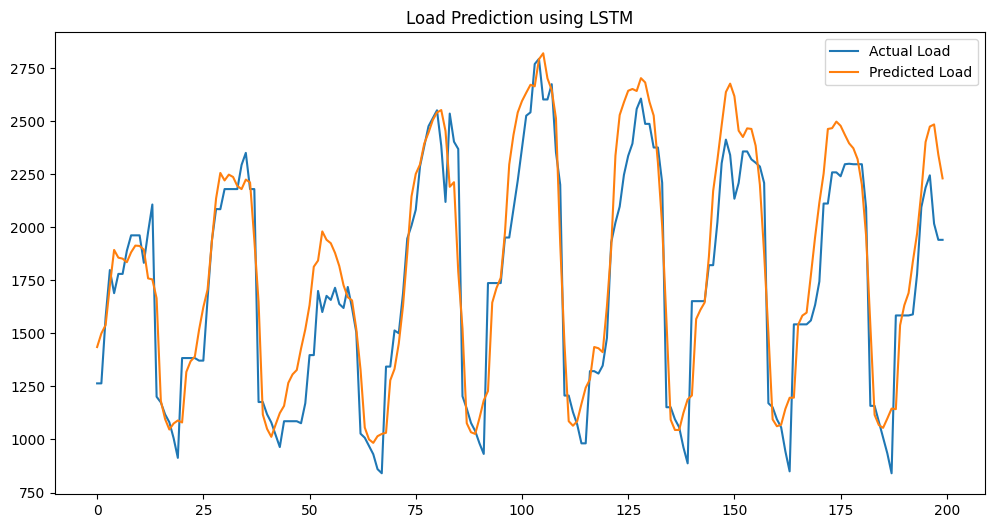

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test[:200], label="Actual Load")
plt.plot(pred[:200], label="Predicted Load")

plt.legend()
plt.title("Load Prediction using LSTM")

plt.show()

Plot between temperature and actual laod

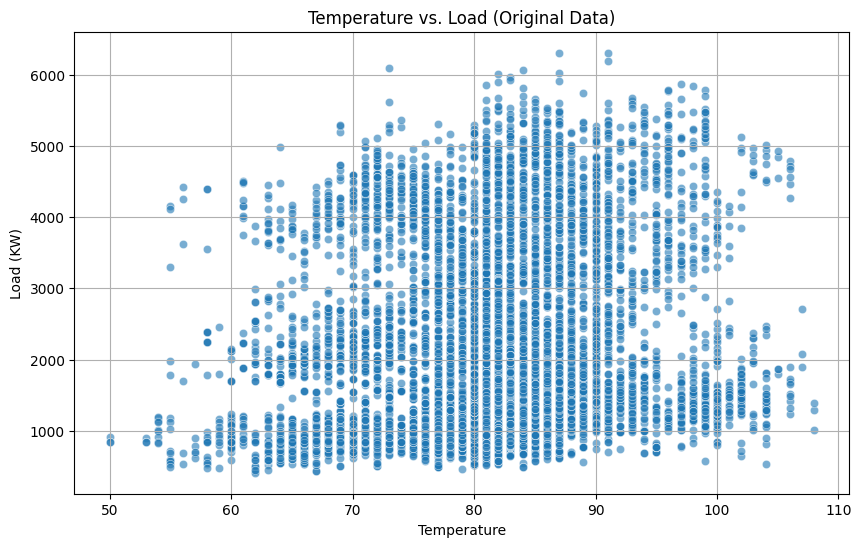

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['temperature'], y=df['load'], alpha=0.6)
plt.title('Temperature vs. Load (Original Data)')
plt.xlabel('Temperature')
plt.ylabel('Load (KW)')
plt.grid(True)
plt.savefig('temperature vs load.png') # Saving the graph
plt.show()

Plot between temperature and predicted load

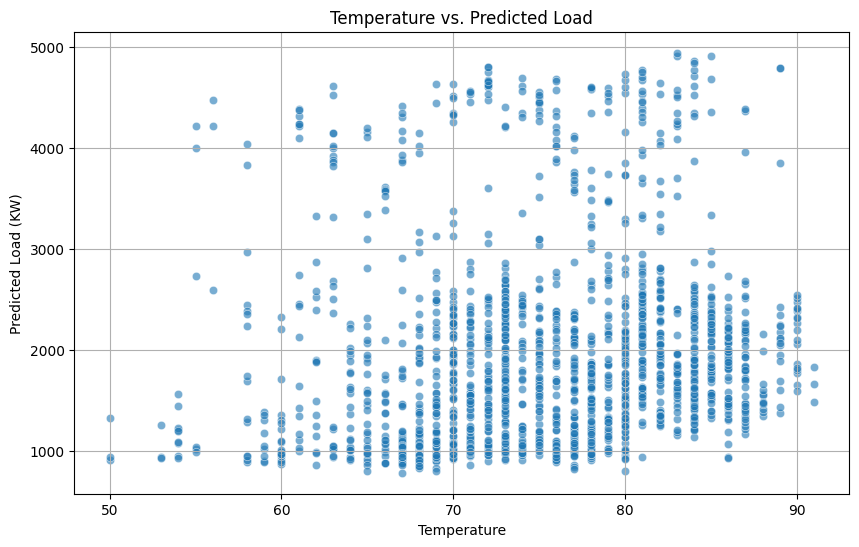

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Get the temperature data corresponding to the test set
# The test set starts at index 'train_size' in X and y.
# 'pred' corresponds to y_test, which are the 'load' values from the original 'df'
# starting from index 'train_size + time_steps' (because 'y' is shifted by 'time_steps')
start_index_for_plot = train_size + time_steps
x_temp_for_plot = df['temperature'].iloc[start_index_for_plot : start_index_for_plot + len(pred)]

sns.scatterplot(x=x_temp_for_plot, y=pred.flatten(), alpha=0.6)
plt.title('Temperature vs. Predicted Load')
plt.xlabel('Temperature')
plt.ylabel('Predicted Load (KW)')
plt.grid(True)
plt.savefig('temperature vs predictedload.png') # Saving the graph
plt.show()
